In [3]:
from joblib import load

# List of all data object names
data_object_names = [
    'X_unseen',
    'y_train',
    'y_unseen',
    'y_val',
    'X_train_encoded',
    'X_val_encoded'
]

# Load each object using joblib and store them in a dictionary
loaded_data_objects = {name: load(f'{name}.joblib') for name in data_object_names}

# Access each loaded object
X_train_scaled_df = loaded_data_objects['X_train_encoded']
X_unseen_scaled_df = loaded_data_objects['X_unseen']
X_val_scaled_df = loaded_data_objects['X_val_encoded']
y_train = loaded_data_objects['y_train']
y_unseen = loaded_data_objects['y_unseen']
y_val = loaded_data_objects['y_val']

Estimate for scale_pos_weight: 171.758
Validation Accuracy: 0.9945501705642373
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    386751
           1       0.52      0.95      0.67      2252

    accuracy                           0.99    389003
   macro avg       0.76      0.97      0.83    389003
weighted avg       1.00      0.99      1.00    389003

Validation Confusion Matrix:
 [[384749   2002]
 [   118   2134]]
Validation ROC AUC Score: 0.9981507618188235
Validation PR AUC Score: 0.9238207207297959


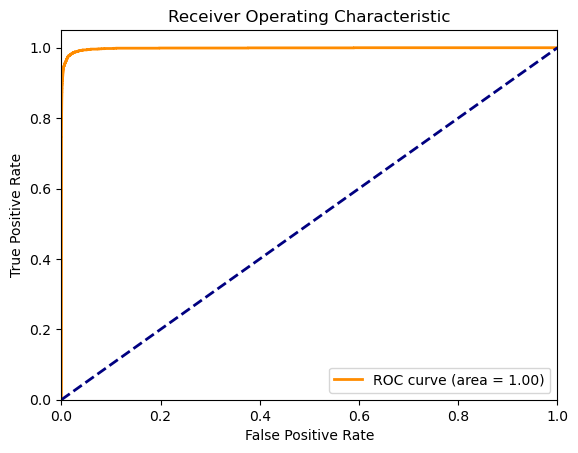

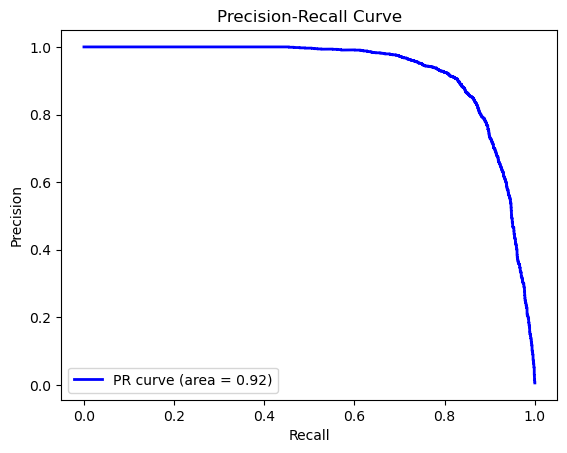

In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from collections import Counter

# Calculate scale_pos_weight
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_scaled_df)
y_val_pred_proba = xgb_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [8]:
%%time
import numpy as np
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(xgb_model, X_train_scaled_df, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 0.9957 ± 0.0002, Test: 0.9948 ± 0.0003
Precision - Train: 0.5737 ± 0.0130, Test: 0.5265 ± 0.0151
Recall - Train: 1.0000 ± 0.0000, Test: 0.9463 ± 0.0072
F1 - Train: 0.7290 ± 0.0105, Test: 0.6765 ± 0.0139
Roc_auc - Train: 0.9999 ± 0.0000, Test: 0.9982 ± 0.0004
CPU times: total: 2min 11s
Wall time: 10.2 s


In [12]:
y_train.value_counts()

is_fraud
0    902418
1      5254
Name: count, dtype: int64

In [16]:
# Necessary imports
import joblib
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve, auc, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Define the parameter grid
param_grid = {
    'scale_pos_weight': [1, 10, 25, 50, 75, 99, 200, 300, 500, 1000],
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42)

# Initialize StratifiedKFold to ensure each fold is stratified
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the HalvingRandomSearchCV
halving_search = HalvingRandomSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    cv=strat_k_fold,
    scoring='f1',  # Use F1 score initially
    random_state=42,
    n_jobs=-1,
    refit=True,
    factor=3,
    max_resources='auto'  # Ensure max_resources is set to auto
)

# Perform the search with threading backend
with joblib.parallel_backend('threading'):
    halving_search.fit(X_train_scaled_df, y_train)

# Best parameters and score
print("Best Parameters:", halving_search.best_params_)
print("Best Cross-Validation F1 Score:", halving_search.best_score_)

C:\Users\Black\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 360 is smaller than n_iter=45383. Running 360 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\Black\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Black\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fil

KeyboardInterrupt: 

C:\Users\Black\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Black\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 371, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 89, in _

In [ ]:
%%time
import joblib
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV

# Define the parameter grid
param_grid = {
    'scale_pos_weight': [1, 10, 25, 50, 75, 99, scale_pos_weight,200, 300, 500, 1000],
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Initialize the HalvingRandomSearchCV
halving_search = HalvingRandomSearchCV(
    xgb_model,
    param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    refit='roc_auc'
)

# Perform the search with threading backend
with joblib.parallel_backend('threading'):
    halving_search.fit(X_train_scaled_df, y_train)

# Best parameters and score
print("Best Parameters:", halving_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", halving_search.best_score_)


C:\Users\Black\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 396 is smaller than n_iter=45383. Running 396 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\Black\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Black\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fil

In [7]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = halving_search.best_estimator_.predict(X_unseen_scaled_df)
y_unseen_pred_proba = halving_search.best_estimator_.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


AttributeError: 'HalvingRandomSearchCV' object has no attribute 'best_estimator_'